<p style="margin: 0;">
  <!-- Left logo stays on the left -->
  <img src="./Images/logo.png" alt="logo" width="280" style="margin-bottom: 0;" />

  <!-- Right-aligned container -->
  <span style="float: right; text-align: right;">
    <img src="./Images/ai_chemy_logo.png"
         alt="ai_chemy logo"
         width="280"
         style="margin-top: 20px; display: block;" />
    <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">
      <img alt="Creative Commons Licence"
           style="border-width: 0; margin-top: 10px; display: block;"
           src="https://i.creativecommons.org/l/by/4.0/88x31.png"
           title="This work is licensed under a Creative Commons Attribution 4.0 International License." />
    </a>
  </span>
</p>
 
 <h1 style="margin-top: 0; text-align: center;">Session 7: Predicting the bioactivity of HIV protease inhibitors
</h1>
<hr style="border: 1px solid black;">

This project has received funding from the AI for Chemistry: AIchemy Hub (EPSRC grant EP/Y028775/1 and EP/Y028759/1) and educational support from the <a href="https://github.com/Edinburgh-Chemistry-Teaching/Data-driven-chemistry">Data-Driven Chemistry</a>  course at the University of Edinburgh’s School of Chemistry.

Authors: 

- Dr Alex Aziz
- Mr Zhaohui Jiang

Email: a.aziz@mmu.ac.uk
<hr style="border: 1px solid black;">


<span style="font-weight: normal; font-size: 16px;">

In this session you will utilize your skills to investigate the bioactivity of a HIV protease inhibitors. Part of this work follows the publication from Gao et al. Machine-learning-based virtual screening and ligand docking identify potent HIV-1 protease inhibitors. Artificial Intelligence Chemistry, 1 (2023), 100014. 
https://doi.org/10.1016/j.aichem.2023.100014.
    
- Query the ChEMBL database for HIV-1 protease
- Screen the SWEETLEAD database for inhibitors.
- Use random forest regression to explore the correlations between molular properties and IC$_{50}$. <br>

</span>

# Importing Modules

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import joblib, json, os

# Import the ChEMBL file

<div class="alert alert-success"><b>🔧 Task 1: Query, write and import the ChemBL file</b> <br>
The ChEMBL data file has been provided for you. You can also create a similar file by following Session 5 and querying for the ChEMBL ID (CHEMBL243). A similar file is also available from the Supporting information section of the Gao et al. paper.

Although you query ChEMBL by the **target** (HIV‑1 protease), the data returned consists of   **compounds tested against that target**, typically reported as IC₅₀ values. In practice, this  means the dataset represents **HIV‑1 protease inhibitors**, even though the query is made using the target name or Target ChEMBL ID.

In [119]:
# Import the file and show the contents
molelcuar_properties = pd.read_csv('./data/Chembl_file.csv') # Make sure the name imported is completely the same with the file's name in your folder。
molelcuar_properties # Show the content of chembl file

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Target Name,Target Organism,Target Type,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties
0,CHEMBL139444,NaN,0,540.68,1,3.76,14,COc1ccc(S(=O)(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc2c...,IC50,'=',...,Human immunodeficiency virus type 1 protease,Human immunodeficiency virus 1,SINGLE PROTEIN,CHEMBL1129709,1,Scientific Literature,Bioorg. Med. Chem. Lett.,1996,NaN,NaN
1,CHEMBL120218,NaN,0,570.73,2,5.93,1n,Cc1ccc(COC(COCc2ccccc2)C(O)C(O)C(COCc2ccccc2)O...,IC50,'=',...,Human immunodeficiency virus type 1 protease,Human immunodeficiency virus 1,SINGLE PROTEIN,CHEMBL1136301,1,Scientific Literature,Bioorg. Med. Chem. Lett.,2003,NaN,NaN
2,CHEMBL16796,NaN,0,611.56,2,6.62,1aa,OC(C(COCc1ccc(Cl)cc1)OCc1ccccc1)C(O)C(COCc1ccc...,IC50,'=',...,Human immunodeficiency virus type 1 protease,Human immunodeficiency virus 1,SINGLE PROTEIN,CHEMBL1136301,1,Scientific Literature,Bioorg. Med. Chem. Lett.,2003,NaN,NaN
3,CHEMBL2092982,NaN,0,544.69,1,4.51,10,CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)[C@@H](O)C[C@@...,IC50,'=',...,Human immunodeficiency virus type 1 protease,Human immunodeficiency virus 1,SINGLE PROTEIN,CHEMBL1125637,1,Scientific Literature,J. Med. Chem.,1991,NaN,NaN
4,CHEMBL337360,NaN,0,300.35,0,3.26,XXVIII,C=CC(C1=C(O)OC2(CCOCC2)CC1=O)c1ccccc1,IC50,'>',...,Human immunodeficiency virus type 1 protease,Human immunodeficiency virus 1,SINGLE PROTEIN,CHEMBL1129402,1,Scientific Literature,J. Med. Chem.,1996,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,CHEMBL302958,NaN,0,823.99,2,2.21,5,CC(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@H](C(...,IC50,'=',...,Human immunodeficiency virus type 1 protease,Human immunodeficiency virus 1,SINGLE PROTEIN,CHEMBL1133785,1,Scientific Literature,Bioorg. Med. Chem. Lett.,2001,NaN,NaN
2012,CHEMBL298189,NaN,0,629.82,1,3.98,5,Cc1cccc(C)c1CNC(=O)[C@H]1N(C(=O)[C@@H](O)C[C@@...,IC50,'=',...,Human immunodeficiency virus type 1 protease,Human immunodeficiency virus 1,SINGLE PROTEIN,CHEMBL1136401,1,Scientific Literature,Bioorg. Med. Chem. Lett.,2003,NaN,NaN
2013,CHEMBL29259,NaN,0,623.75,1,3.38,LY-300217,Cc1ccc(C(=O)NC(C)(C)C)c(C[C@@H](O)[C@H](Cc2ccc...,IC50,'=',...,Human immunodeficiency virus type 1 protease,Human immunodeficiency virus 1,SINGLE PROTEIN,CHEMBL1151581,1,Scientific Literature,Bioorg. Med. Chem. Lett.,1994,NaN,NaN
2014,CHEMBL4633067,NaN,0,516.66,1,1.23,m8,C[C@@H]1CN(CC(=O)N[C@@H](Cc2ccccc2)[C@H](O)CN(...,IC50,'=',...,Human immunodeficiency virus type 1 protease,Human immunodeficiency virus 1,SINGLE PROTEIN,CHEMBL4616626,1,Scientific Literature,Bioorg Med Chem Lett,2020,NaN,NaN


# PaDEL‑Descriptor
The work by Gao et al. PaDEL-Descriptor (https://github.com/ecrl/padelpy) was used to calculate molecular fingerprints. 

PaDEL‑Descriptor is a widely used, open‑source software tool for calculating molecular descriptors and fingerprints from chemical structures. It is designed for quantitative structure–activity/property relationship (QSAR/QSPR) modelling, cheminformatics, and machine‑learning workflows. PaDEL can be run directly via a Python wrapper padelpy which can be installed using pip.

In this session, you are provided with an example of how PaDEL‑Descriptor can be used in Python via padelpy. This example is for demonstration only — you will not be required to run it, because our regression models in this tutorial will use the molecular descriptors already provided from ChEMBL.

## About Fingerprints in PaDEL
The code in given in this section (using padeldescriptor with fingerprints=True) will generate all PaDEL fingerprint types.
These include several different structural encodings, for example:

PubChem fingerprints (881 bits)
Substructure fingerprints (1024 bits)
MACCS keys (166 bits)
Estate, Graph, Klekota–Roth, and other fingerprint families

Using all fingerprints produces a large feature set (often several thousand bits), which can be useful for broad QSAR modelling but increases computation time.

If you only wnat the PubChem figerprints then you must include the an xml file. Click on the following section to find out more about molecular fingerprints.

<details>
<summary><strong>What Are Molecular Fingerprints?</strong> (click to expand)</summary>

<br>

**Molecular fingerprints** are fixed‑length vectors that encode the presence or absence of specific structural features in a molecule. They convert a SMILES string into a numeric format that machine‑learning models can use for QSAR/QSPR tasks, clustering, similarity search, and classification.

### **Types of Fingerprints in PaDEL**

#### **1. PubChem Fingerprints (881 bits)**
- A predefined list of 881 chemical fragments from the PubChem database.
- Capture functional groups, ring systems, heterocycles, and common structural motifs.
- Good balance between size and chemical coverage.
- Commonly used for Random Forest and QSAR modelling.

#### **2. Substructure Fingerprints (1024 bits)**
- Hashed fingerprints derived from all structural fragments detected in a molecule.
- Not restricted to a fixed list of patterns.
- Larger, more expressive, but often sparse.

#### **3. MACCS Keys (166 bits)**
- A small set of 166 curated yes/no chemical keys.
- Very compact but less descriptive.
- Useful for lightweight models and teaching.

#### **4. Other Specialized Fingerprints**
- Estate fingerprints: electronic + topological info.
- Graph-based fingerprints: path and subgraph patterns.
- Klekota–Roth fingerprints: large pharmacophore patterns.

---

### **Why the Differences Matter**
Each fingerprint type describes molecules at a different level:

- **PubChem FP** → interpretable, moderate size (881 bits), excellent for QSAR  
- **Substructure FP** → broad and detailed, captures many fragment types  
- **MACCS Keys** → very compact, low‑dimensional  
- **Others** → specialized for pharmacophore or graph‑theory applications  

Using **all fingerprints** results in thousands of features and longer computation times.

Using **only PubChem FP** keeps things simple and fast while retaining strong predictive performance.

---

### **How to Generate ONLY PubChem Fingerprints**
PaDEL generates all fingerprints by default.  
To restrict output to **PubChem fingerprints only**, use this configuration file:

#### **`pubchem_only.xml`**
```xml
<?xml version="1.0" encoding="UTF-8"?>
<PaDELDescriptor>
    <Fingerprints>
        <PubchemFingerprinter>
        </PubchemFingerprinter>
    </Fingerprints>
    <RemoveSalt>true</RemoveSalt>
    <StandardizeNitro>true</StandardizeNitro>
</PaDELDescriptor>

In [129]:
#pip install padelpy

In [125]:
import pandas as pd
from padelpy import from_smiles
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---- Config ----
INPUT_CSV = "./data/Chembl_file.csv"
SMILES_COL = "Smiles"   # change if your column is e.g., "SMILES"
ID_COL = "id"           # set to None if you don't have an ID column
N_THREADS = 8           # adjust to your CPU
COMPUTE_FPS = True      # set to False if you only want descriptors

# ---- Load data ----
df = pd.read_csv(INPUT_CSV)
if SMILES_COL not in df.columns:
    raise ValueError(f"Column '{SMILES_COL}' not found in CSV.")
if ID_COL and ID_COL not in df.columns:
    print(f"Warning: ID column '{ID_COL}' not found. Will create a row index instead.")
    ID_COL = None

# Create an ID if missing
if not ID_COL:
    df["__row_id"] = range(1, len(df) + 1)
    ID_COL = "__row_id"

smiles_list = df[SMILES_COL].astype(str).tolist()
ids_list = df[ID_COL].tolist()

# ---- Worker function ----
def compute_features(record_id, smi):
    try:
        # descriptors only
        desc = from_smiles(smi, fingerprints=False)
        if COMPUTE_FPS:
            fps = from_smiles(smi, descriptors=False, fingerprints=True)
            desc.update(fps)
        desc[ID_COL] = record_id
        return desc, None
    except Exception as e:
        return None, (record_id, str(e))

# ---- Parallel run ----
results = []
errors = []
with ThreadPoolExecutor(max_workers=N_THREADS) as ex:
    futures = [ex.submit(compute_features, rid, smi) for rid, smi in zip(ids_list, smiles_list)]
    for fut in as_completed(futures):
        res, err = fut.result()
        if res is not None:
            results.append(res)
        if err is not None:
            errors.append(err)

# ---- Build output DataFrame ----
out_df = pd.DataFrame(results)
# Keep original order by merging back on ID
final = df[[ID_COL, SMILES_COL]].merge(out_df, on=ID_COL, how="left")

final.to_csv("padel_descriptors.csv", index=False)
print(f"Done. Wrote {len(final)} rows to padel_descriptors.csv")
if errors:
    print(f"{len(errors)} molecules failed. See 'padel_errors.csv'")
    pd.DataFrame(errors, columns=[ID_COL, "error"]).to_csv("padel_errors.csv", index=False)

Done. Wrote 2016 rows to padel_descriptors.csv
59 molecules failed. See 'padel_errors.csv'


In [30]:
df=molelcuar_properties # Assign the name df moleluar_properties.

<div class="alert alert-block alert-info">
<b>Note:</b> In this session we use only the three molecular descriptors provided in the ChEMBL file (Molecular Weight, AlogP, and #RO5 Violations), which are sufficient for demonstrating the QSAR workflow. ChEMBL activity exports do not include any additional structural descriptors.
If more features are needed—such as fingerprints or larger descriptor sets—they must be generated separately using tools like PaDEL‑Descriptor.

This means the machine learning model (Random Forest, etc.) will be trained using only these three descriptors as input.
</div>



In [146]:
# Ensure the column names are the same as your imported ChEMBL file.
cols1 = ['Molecular Weight', '#RO5 Violations', 'AlogP'] 

# Assign all molular properties to X the independent variable.
X = df[cols1] 

# Show the X Dataframe.
X

,Molecular Weight,#RO5 Violations,AlogP
0,540.68,1,3.76
1,570.73,2,5.93
2,611.56,2,6.62
3,544.69,1,4.51
4,300.35,0,3.26
...,...,...,...
2011,823.99,2,2.21
2012,629.82,1,3.98
2013,623.75,1,3.38
2014,516.66,1,1.23


**Assign the pIC$_{50}$ values to y**

The IC₅₀ values in the dataset were originally reported in nanomolar (nM), so they were converted to pIC₅₀ for modelling. pIC₅₀ is the negative logarithm of the molar IC₅₀ value and is preferred because biological  potency is naturally logarithmic and easier for machine learning models to analyse, a larger pIC₅₀ indicates stronger  activity, and the distribution is more suitable for machine‑learning models.

To convert IC₅₀ (in nM) to pIC₅₀ (in molar units), the values were first  scaled to molar (IC₅₀ × 10⁻⁹), then the negative log₁₀ was applied:

**pIC$_{50}$ = −log$_{10}$(IC$_{50}$ × 10$^{-9}$)**.

In [174]:
# Assign the IC50 values as a y dependent Dataframe.
y = df['Standard Value']

# Take base-10 logarithm of each element in y.
y = 9- np.log10(y)

y

0        8.301030
1        5.431798
2        5.283997
3        6.640165
4        5.000000
          ...    
2011     7.309804
2012    10.397940
2013     8.657577
2014     5.815309
2015     9.000000
Name: Standard Value, Length: 2016, dtype: float64

# Linear Regression model
In the below you train and test a linear regression model

In [181]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [183]:
y_pred_train = model.predict(X_train)

In [185]:
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(y_train, y_pred_train))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(y_train, y_pred_train))

Coefficients: [ 0.00665339 -0.50768285  0.13329943]
Intercept: 3.372220276321592
Mean squared error (MSE): 2.34
Coefficient of determination (R^2): 0.18


In [258]:
predicted_yintercept = '%.3f' % model.intercept_
predicted_MW = '%.3f MW' % model.coef_[0]
predicted_RO5 = '%.3f RO5' % model.coef_[1]
predicted_AlogP = '%.3f AlogP' % model.coef_[2]

# Print the Regression equation
print(f"pIC50 = {model.intercept_:.3f} {model.coef_[0]:+.3f}·MW {model.coef_[1]:+.3f}·RO5 {model.coef_[2]:+.3f}·AlogP")

#or

# Print the Regression equation using the newly assigned variables.
print(f"pIC50 = {predicted_yintercept} + {predicted_MW} {predicted_RO5} + {predicted_AlogP}")

pIC50 = 3.372 +0.007·MW -0.508·RO5 +0.133·AlogP
pIC50 = 3.372 + 0.007 MW -0.508 RO5 + 0.133 AlogP


In [ ]:
* Regression equation
> pIC$_{50}$ = 5.5286 -0.0066 MW + 0.5581 RO5 violation -0.1357 AlogP

<div class="alert alert-success"><b>🔧 Task 2: Plot the actual versus predicted data using a scatter plot ensure the axis are appropriately labelled.</b> <br>

<div class="alert alert-success"><b>🔧 Task 3: Comment on the correlation</b> <br>

<div class="alert alert-success"><b>🔧 Task 4. Repeat the model fitting using at least 3 different train–test splits and create a table of your results below.</b> <br>

<div class="alert alert-success"><b>🔧 Task 5. Comment on your results.</b> <br>

# Random Forest regression

In the last session you were introduced to Random Forest regression and GNNs. In this tutorial we use a Random Forest regression model to predict pIC₅₀ values from molecular fingerprints.

There are many machine‑learning models that can be applied to QSAR problems. To compare different algorithms, the LazyPredict package can be used to quickly test regression models and give an initial indication of which approaches perform best. In the work by Gao et al. 40 regression models were tested and they identified Random Forest as giving the best results on the ChEMBL data.

This code below imports the Random Forest module and splits the dataset into training (80%) and test (20%) sets using train_test_split. A Random Forest Regressor with 100 trees is then trained on the training data. After training, the model makes predictions on both the training and test sets. Finally, the code prints the Mean Squared Error (MSE) and R² score for each split, allowing you to evaluate how well the model performs on data it has seen (training) and on new unseen data (test).

In the code below the number of trees (n_estimators) is set to 100. Although you use only three molecular descriptors, Random Forest still benefits from using many trees. Each tree is trained on a different random sample of the data, and averaging 100 trees gives a much more stable and reliable prediction than using just a few. The number of trees improves model stability, not the number of input features.

In [268]:
from sklearn.ensemble import RandomForestRegressor

In [270]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)  
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

print('Mean squared error (MSE) on train: %.2f' % mean_squared_error(y_train, y_pred_train))
print('Coefficient of determination (R^2) on train: %.2f' % r2_score(y_train, y_pred_train))

print('Mean squared error (MSE) on test:  %.2f' % mean_squared_error(y_test, y_pred_test))
print('Coefficient of determination (R^2) on test:  %.2f' % r2_score(y_test, y_pred_test))


Mean squared error (MSE) on train: 0.34
Coefficient of determination (R^2) on train: 0.88
Mean squared error (MSE) on test:  1.50
Coefficient of determination (R^2) on test:  0.48


The Random Forest’s feature_importances_ shows how much each descriptor contributed to the model’s predictions. Higher values mean the feature had a greater influence, helping us understand which molecular properties are most important for predicting pIC₅₀. This is output with the code below.

In [274]:
feat_imp = rf.feature_importances_
print("\nFeature importances (same order as cols):")
for name, imp in zip(cols1, feat_imp):
    print(f"{name}: {imp:.6f}")


Feature importances (same order as cols):
Molecular Weight: 0.442578
#RO5 Violations: 0.203949
AlogP: 0.353473


<div class="alert alert-block alert-info"> <b>Note:</b> The code below generates two scatter plots that compare the model’s predicted pIC₅₀ values with the actual experimental values for both the training set and test set. For each plot, it adds:

a best‑fit trendline (using np.polyfit)
a y = x reference line to show perfect predictions
the R² score to summarize accuracy

Finally, the figure is formatted neatly and saved as PNG and PDF.

The `ravel()` NumPy array method is used to flatten the array from a 2‑D shape `(n, 1)` into a 1‑D vector `(n,)`, which is required because plotting and numerical functions like `polyfit` expect 1‑dimensional inputs.

Shapes -> train: (1612,) (1612,) ; test: (404,) (404,)


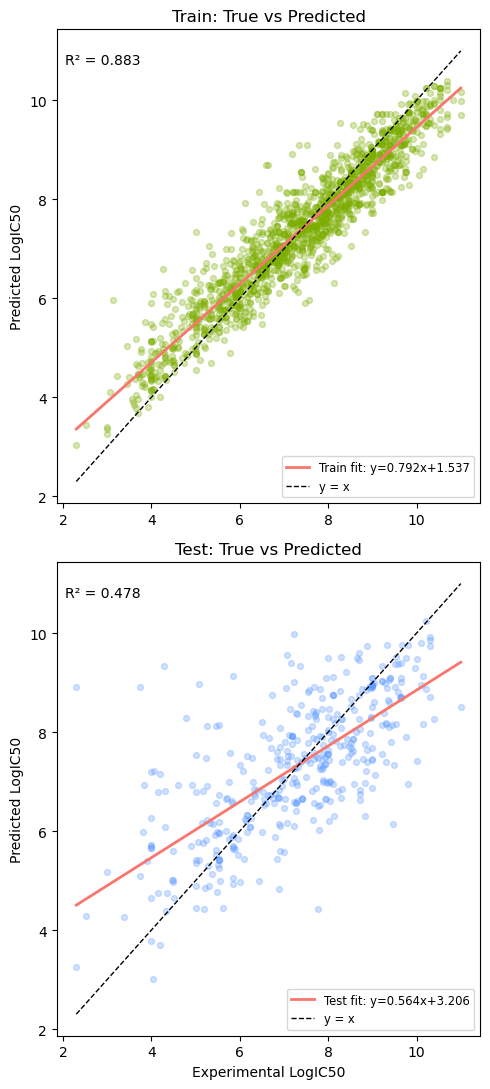

In [279]:
Y_train = np.asarray(y_train).ravel()
Y_pred_train = np.asarray(y_pred_train).ravel()
Y_test = np.asarray(y_test).ravel()
Y_pred_test = np.asarray(y_pred_test).ravel()

print("Shapes -> train:", Y_train.shape, Y_pred_train.shape, "; test:", Y_test.shape, Y_pred_test.shape)

plt.figure(figsize=(5,11))  

plt.subplot(2, 1, 1)
plt.scatter(Y_train, Y_pred_train, c="#7CAE00", alpha=0.3, s=18)   # train scatter

z_train = np.polyfit(Y_train, Y_pred_train, 1)      # slope, intercept
p_train = np.poly1d(z_train)

x_line_train = np.linspace(Y_train.min(), Y_train.max(), 200)
plt.plot(x_line_train, p_train(x_line_train), color="#F8766D", linewidth=2, label=f"Train fit: y={z_train[0]:.3f}x+{z_train[1]:.3f}")

xmin = min(Y_train.min(), Y_pred_train.min())
xmax = max(Y_train.max(), Y_pred_train.max())
plt.plot([xmin, xmax], [xmin, xmax], 'k--', linewidth=1, label='y = x')

r2_tr = r2_score(Y_train, Y_pred_train)
plt.text(0.02, 0.95, f"R² = {r2_tr:.3f}", transform=plt.gca().transAxes, va='top')

plt.ylabel('Predicted LogIC50')
plt.title('Train: True vs Predicted')
plt.legend(loc='lower right', fontsize='small')


plt.subplot(2, 1, 2)
plt.scatter(Y_test, Y_pred_test, c="#619CFF", alpha=0.3, s=18)    # test scatter

z_test = np.polyfit(Y_test, Y_pred_test, 1)
p_test = np.poly1d(z_test)
x_line_test = np.linspace(Y_test.min(), Y_test.max(), 200)
plt.plot(x_line_test, p_test(x_line_test), color="#F8766D", linewidth=2, label=f"Test fit: y={z_test[0]:.3f}x+{z_test[1]:.3f}")


xmin_t = min(Y_test.min(), Y_pred_test.min())
xmax_t = max(Y_test.max(), Y_pred_test.max())
plt.plot([xmin_t, xmax_t], [xmin_t, xmax_t], 'k--', linewidth=1, label='y = x')

r2_te = r2_score(Y_test, Y_pred_test)
plt.text(0.02, 0.95, f"R² = {r2_te:.3f}", transform=plt.gca().transAxes, va='top')

plt.ylabel('Predicted LogIC50')
plt.xlabel('Experimental LogIC50')
plt.title('Test: True vs Predicted')
plt.legend(loc='lower right', fontsize='small')

plt.tight_layout()
plt.savefig('plot_vertical_logIC50_improved.png', dpi=300, bbox_inches='tight')
plt.savefig('plot_vertical_logIC50_improved.pdf', dpi=300, bbox_inches='tight')
plt.show()


<div class="alert alert-success"><b>🔧 Task 6. Comment on your results.</b> <br>

This code below saves the trained Random Forest model plus its metadata (features, parameters, feature importances, and training statistics) so the model can be reused, reproduced, and deployed without needing to retrain it.

In [290]:
# Save the model and related information

from datetime import datetime
import os, json, joblib

os.makedirs('models', exist_ok=True)

# output directory
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# Model filename
model_fname = f'models/rf_model_{ts}.joblib'

# Save Model
joblib.dump(rf, model_fname)
print("Saved model to:", model_fname)

# Determine feature list
FEATURES = cols1 if 'cols1' in globals() else ['Molecular Weight', '#RO5 Violations', 'AlogP']

# Save feature importances 
feat_imp = rf.feature_importances_ if hasattr(rf, 'feature_importances_') else (feat_imp if 'feat_imp' in globals() else None)

# Save metadata (includes model params, feature order, feature importances)
metadata = {
    'saved_at': ts,
    'model_file': model_fname,
    'features': FEATURES,
    'n_estimators': getattr(rf, 'n_estimators', None),
    'random_state': getattr(rf, 'random_state', None),
    'n_jobs': getattr(rf, 'n_jobs', None),
    'feature_importances': list(feat_imp) if feat_imp is not None else None,
    'note': 'Trained with your provided code: RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)'
}
meta_fname = f'models/metadata_{ts}.json'
with open(meta_fname, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("Saved metadata to:", meta_fname)

# Save training-set statistics (min/max/median) 
if 'X_train' in globals():
    train_stats = {c: {'min': float(X_train[c].min()), 'max': float(X_train[c].max()), 'median': float(X_train[c].median())}
                   for c in FEATURES}
    stats_fname = f'models/train_stats_{ts}.joblib'
    joblib.dump(train_stats, stats_fname)
    print("Saved train_stats to:", stats_fname)
else:
    print("Warning: X_train not found in globals(); train_stats not saved.")

Saved model to: models/rf_model_20260217_133546.joblib
Saved metadata to: models/metadata_20260217_133546.json
Saved train_stats to: models/train_stats_20260217_133546.joblib


# SWEETLEAD Database
Now that your Random Forest model has been trained on ChEMBL HIV‑1 protease bioactivity data and saved, you can apply it to a new chemical library. In this next step, we use the SWEETLEAD database, a curated collection of approved drugs, natural products, and bioactive compounds to predict their pIC₅₀ values with the model. The goal is to identify novel or repurposable HIV‑1 protease inhibitors by finding SWEETLEAD molecules that the model predicts to have high potency.

In [318]:
# Load the SWEETLEAD data file and predict IC50 values using existing molecular features
import joblib, os

# 1) Load the trained Random Forest model
#    If you just ran the model‑saving cell, model_fname already contains the correct file.
#    Otherwise, replace model_path with the filename of the saved .joblib model.
model_path = model_fname  
rf_loaded = joblib.load(model_path)
print("Loaded model from:", model_path)

# 2) Load the training statistics (optional)
#    These statistics (min/max/median of each feature) are saved during training.
#    They allow you to check whether new molecules fall within the range of the training data.
stats_path = stats_fname if 'stats_fname' in globals() else None
train_stats = joblib.load(stats_path) if (stats_path and os.path.exists(stats_path)) else None

# 3) Load the new dataset of molecules to predict (here: SWEETLEAD)
#    This file must contain the SAME descriptor columns used to train the model 
#    (Molecular Weight, AlogP, and #RO5 Violations).
df_new = pd.read_csv('./data/SWEETLEAD.csv')

Loaded model from: models/rf_model_20260217_133546.joblib


<div class="alert alert-block alert-info"> <b>Note:</b> To confirm that the SweetLead dataset contains the same three descriptors used to train our model: Molecular Weight, AlogP, and #RO5 Violations. Use df_new.columns to check the column names directly, ensuring that the required features are present. Because the SweetLead data includes these descriptors, it can be safely passed into the trained Random Forest model to generate predicted pIC₅₀ values.

In [321]:
df_new.columns

Index(['orig_index', 'Isomeric Smiles', 'Molecular Weight', 'AlogP',
       'H_donors', 'H_acceptors', '#RO5 Violations', 'MW', 'LogP',
       'RO5_violations'],
      dtype='object')

In [325]:
# 4) Prepare the input features and make predictions
#    Extract only the SAME descriptor columns (FEATURES) that the model was trained on.
#    Since the model was trained directly on the raw descriptor values (without scaling or preprocessing), 
#    we can pass the SweetLead descriptors directly to the model for prediction.
#    Pass the raw numerical values directly as a NumPy array into the model's predict() function.
X_new_for_pred = df_new[FEATURES]
y_pred = rf_loaded.predict(X_new_for_pred)

# 5) Add the predicted pIC50 values to the SWEETLEAD dataset and save the results
#    The predictions are stored in a new column so we can easily inspect, rank, or filter compounds.
#    The final table with predictions is saved to a CSV file for further analysis or visualization.
df_new['predicted_pIC50'] = y_pred
out_fname = 'descriptors_with_predictions.csv'
df_new.to_csv(out_fname, index=False)
print("Predictions saved to:", out_fname)

Predictions saved to: descriptors_with_predictions.csv


In [300]:
# Print the top 10 predictions
TOP_N = 10

df_top10 = df_new.sort_values(by='predicted_pIC50', ascending=False).head(TOP_N).reset_index(drop=True)
top_fname = 'top10_predictions.csv'

df_top10.to_csv(top_fname, index=False)
print(f"Top {TOP_N} saved to: {top_fname}")

Top 10 saved to: top10_predictions.csv


<div class="alert alert-success"><b>🔧 Optional Task. Use the padel_descriptors.csv file supplied to increase the number of features and improve the Random Forest regression model.</b> <br>

<h1 style="margin-top: 0; text-align: center;">End of Session</h1>